# 💻 Laptop Price Prediction — End-to-End ML Pipeline

**Objective:** Predict laptop prices using a complete machine learning pipeline.

**Preprocessing Pipeline (from marketing notebook):**
1. Initial Data Inspection
2. Handling Missing Values
3. Duplicate Detection
4. Outlier Analysis & Capping
5. Feature Engineering
6. Encoding Categorical Features
7. Scaling
8. Feature Selection

**Modeling Pipeline (from Session 9 style):**
- Baseline Models
- GridSearchCV Tuning
- Final Evaluation & Comparison

## 0. Install & Import Libraries

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Global styling for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Utility function for evaluation
results_log = {}

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    results_log[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

    print(f"--- {name} Performance ---")
    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}\n")

---
## 1. Initial Data Inspection

In [16]:
df = pd.read_csv("/content/laptop_price.csv", encoding='latin1')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Shape: 1,303 rows × 13 columns


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [18]:
print('SUMMARY STATISTICS')
df.describe().T.style.background_gradient(cmap='Blues', axis=1)

SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,max
laptop_ID,1303.000000,660.155794,381.172104,1.000000,331.500000,659.000000,990.500000,1320.000000
Inches,1303.000000,15.017191,1.426304,10.100000,14.000000,15.600000,15.600000,18.400000
Price_euros,1303.000000,1123.686992,699.009043,174.000000,599.000000,977.000000,1487.880000,6099.000000


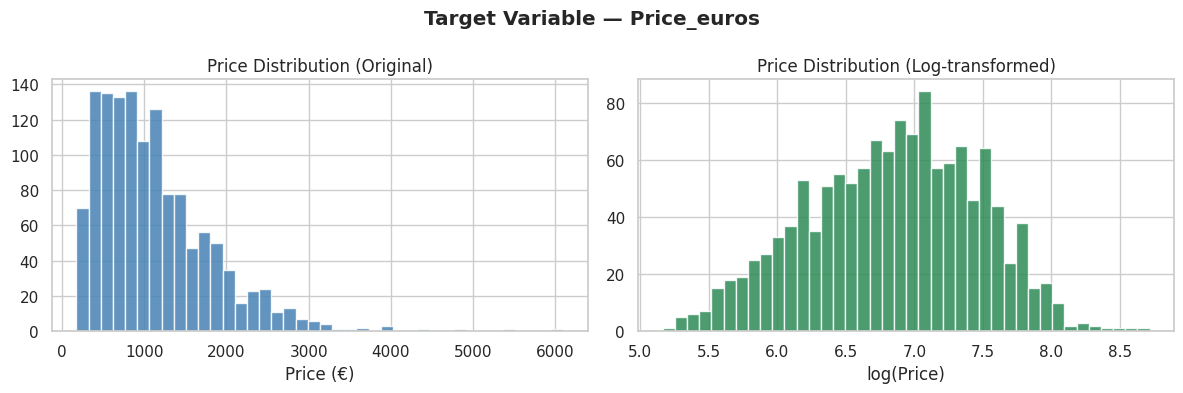

In [19]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Price_euros'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Price Distribution (Original)')
axes[0].set_xlabel('Price (€)')

axes[1].hist(np.log1p(df['Price_euros']), bins=40, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('Price Distribution (Log-transformed)')
axes[1].set_xlabel('log(Price)')

plt.suptitle('Target Variable — Price_euros', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Handling Missing Values

We check for nulls and fill any numeric missing values with the **median** (robust to outliers).

In [20]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64


In [21]:
# Fill missing numeric values with median
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print('Missing after fill:', df.isnull().sum().sum())

Missing after fill: 0


---
## 3. Duplicate Detection

In [22]:
print(f'Duplicate rows: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
print(f'Shape after removing duplicates: {df.shape}')

Duplicate rows: 0
Shape after removing duplicates: (1303, 13)


---
## 4. Outlier Analysis & Capping

We visualize outliers using boxplots, then cap them using the **IQR method** — values below Q1−1.5×IQR or above Q3+1.5×IQR are clipped to the boundary.

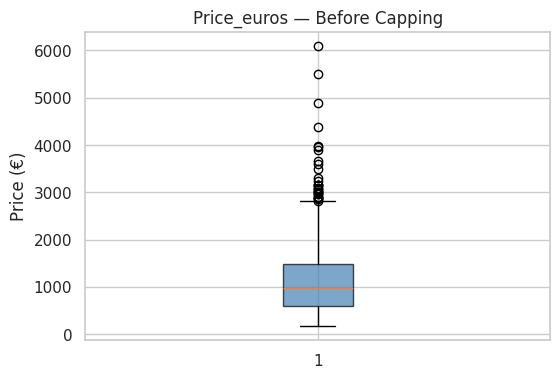

In [23]:
# Boxplot before capping
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(df['Price_euros'], patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.7))
ax.set_title('Price_euros — Before Capping')
ax.set_ylabel('Price (€)')
plt.show()

In [24]:
# IQR Capping on Price_euros only (target)
Q1 = df['Price_euros'].quantile(0.25)
Q3 = df['Price_euros'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_before = ((df['Price_euros'] < lower) | (df['Price_euros'] > upper)).sum()
df['Price_euros'] = df['Price_euros'].clip(lower, upper)

print(f'Outliers capped: {outliers_before}')
print(f'Price range after capping: {df["Price_euros"].min():.0f}€ → {df["Price_euros"].max():.0f}€')

Outliers capped: 29
Price range after capping: 174€ → 2821€


---
## 5. Feature Engineering

We extract useful numeric features from raw text columns:
- `Ram` → numeric GB
- `Weight` → numeric kg
- `ScreenResolution` → `IPS`, `Touchscreen`, `PPI`
- `Cpu` → `CpuBrand`, `CpuGHz`
- `Gpu` → `GpuBrand`
- `Memory` → `SSD_GB`, `HDD_GB`, `HasSSD`

In [69]:
df_clean = df.copy()

# Drop useless columns
df_clean.drop(['laptop_ID', 'Product'], axis=1, inplace=True)

# Ram & Weight
df_clean['Ram'] = df_clean['Ram'].str.replace('GB','').astype(int)
df_clean['Weight'] = df_clean['Weight'].str.replace('kg','').astype(float)

# Screen features
df_clean['IPS'] = df_clean['ScreenResolution'].str.contains('IPS').astype(int)
df_clean['Touchscreen'] = df_clean['ScreenResolution'].str.contains('Touch').astype(int)
df_clean['Retina'] = df_clean['ScreenResolution'].str.contains('Retina').astype(int)

res = df_clean['ScreenResolution'].str.extract(r'(\d+)x(\d+)').astype(float)

df_clean['PPI'] = (
    np.sqrt(res[0]**2 + res[1]**2) / df_clean['Inches']
).round(2)

df_clean.drop('ScreenResolution', axis=1, inplace=True)

# CPU
def get_cpu_brand(cpu_str):
    if 'Intel' in cpu_str: return 'Intel'
    if 'AMD' in cpu_str: return 'AMD'
    return 'Other'
df_clean['CpuBrand'] = df_clean['Cpu'].apply(get_cpu_brand)
df_clean['CpuGHz'] = df_clean['Cpu'].str.extract(r'(\d+\.\d+)GHz')[0].astype(float)
df_clean['CpuGHz'] = df_clean['CpuGHz'].fillna(df_clean['CpuGHz'].median())
df_clean.drop('Cpu', axis=1, inplace=True)

# GPU
def get_gpu_brand(gpu_str):
    if 'Nvidia' in gpu_str: return 'Nvidia'
    if 'AMD' in gpu_str: return 'AMD'
    if 'Intel' in gpu_str: return 'Intel'
    return 'Other'
df_clean['GpuBrand'] = df_clean['Gpu'].apply(get_gpu_brand)
df_clean.drop('Gpu', axis=1, inplace=True)

# Memory (simplified but same logic)
def parse_memory(mem):
    ssd, hdd = 0, 0

    for part in str(mem).split('+'):
        part = part.upper()

        num = ''.join([c for c in part if c.isdigit() or c == '.'])
        if num == '':
            continue

        size = float(num)

        if 'TB' in part:
            size *= 1024

        if 'SSD' in part or 'NVME' in part or 'FLASH' in part:
            ssd += size
        else:
            hdd += size

    return ssd, hdd


df_clean[['SSD_GB', 'HDD_GB']] = df_clean['Memory'].apply(
    lambda x: pd.Series(parse_memory(x))
)

df_clean['HasSSD'] = (df_clean['SSD_GB'] > 0).astype(int)

df_clean.drop('Memory', axis=1, inplace=True)

print(df_clean.shape)
df_clean.head(3)

(1303, 17)


,Company,TypeName,Inches,Ram,OpSys,Weight,Price_euros,IPS,Touchscreen,Retina,PPI,CpuBrand,CpuGHz,GpuBrand,SSD_GB,HDD_GB,HasSSD
0,Apple,Ultrabook,13.3,8,macOS,1.37,1339.69,1,0,1,226.98,Intel,2.3,Intel,128.0,0.0,1
1,Apple,Ultrabook,13.3,8,macOS,1.34,898.94,0,0,0,127.68,Intel,1.8,Intel,128.0,0.0,1
2,HP,Notebook,15.6,8,No OS,1.86,575.00,0,0,0,141.21,Intel,2.5,Intel,256.0,0.0,1


---
## 6. Encoding Categorical Features

- `CpuBrand`, `GpuBrand` → **Label Encoding** (low cardinality, no order)
- `Company`, `TypeName`, `OpSys` → **One-Hot Encoding**

In [26]:
print('Categorical columns and cardinality:')
for col in df_clean.select_dtypes(include='object').columns:
    print(f'  {col}: {df_clean[col].nunique()} unique → {df_clean[col].unique()[:5]}')

Categorical columns and cardinality:
  Company: 19 unique → ['Apple' 'HP' 'Acer' 'Asus' 'Dell']
  TypeName: 6 unique → ['Ultrabook' 'Notebook' 'Netbook' 'Gaming' '2 in 1 Convertible']
  OpSys: 9 unique → ['macOS' 'No OS' 'Windows 10' 'Mac OS X' 'Linux']
  CpuBrand: 3 unique → ['Intel' 'AMD' 'Other']
  GpuBrand: 3 unique → ['Intel' 'AMD' 'Nvidia']


In [27]:
# Label Encode — CpuBrand, GpuBrand (binary/low cardinality)
le = LabelEncoder()
for col in ['CpuBrand', 'GpuBrand']:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# One-Hot Encode — Company, TypeName, OpSys
df_clean = pd.get_dummies(df_clean, columns=['Company', 'TypeName', 'OpSys'])

# Convert bool columns to int
bool_cols = df_clean.select_dtypes(bool).columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

print(f'Shape after encoding: {df_clean.shape}')
df_clean.head(3)

Shape after encoding: (1303, 48)


,Inches,Ram,Weight,Price_euros,IPS,Touchscreen,Retina,PPI,CpuBrand,CpuGHz,...,TypeName_Workstation,OpSys_Android,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
0,13.3,8,1.37,1339.69,1,0,1,226.98,1,2.3,...,0,0,0,0,0,0,0,0,0,1
1,13.3,8,1.34,898.94,0,0,0,127.68,1,1.8,...,0,0,0,0,0,0,0,0,0,1
2,15.6,8,1.86,575.00,0,0,0,141.21,1,2.5,...,0,0,0,0,0,1,0,0,0,0


---
## 7. Train / Test Split + Scaling

**Important:** Split first, then fit scaler on train only — apply to both.

In [28]:
X = df_clean.drop(columns=['Price_euros'])
y = np.log1p(df_clean['Price_euros'])   # log-transform: price is right-skewed

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# IQR Capping on features — learn from train only
num_feat_cols = X_train.select_dtypes(include='number').columns.tolist()
bounds = {}
for col in num_feat_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    bounds[col] = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

for col, (lo, hi) in bounds.items():
    X_train[col] = X_train[col].clip(lo, hi)
    X_test[col]  = X_test[col].clip(lo, hi)

print('Capping done — bounds learned from train only')

# Scaling — fit on train only
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

print('Scaling done')
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Capping done — bounds learned from train only
Scaling done
Train: (1042, 47) | Test: (261, 47)


---
## 8. Feature Selection

Two steps:
1. **VarianceThreshold** — remove zero-variance (constant) columns
2. **Correlation Filter** — remove one of any pair with correlation > 0.95

In [29]:
# Step 1 — VarianceThreshold
selector = VarianceThreshold(threshold=0.0)
X_train_arr = selector.fit_transform(X_train_scaled)
X_test_arr  = selector.transform(X_test_scaled)
selected_cols = X_train_scaled.columns[selector.get_support()].tolist()
X_train_scaled = pd.DataFrame(X_train_arr, columns=selected_cols)
X_test_scaled  = pd.DataFrame(X_test_arr,  columns=selected_cols)
print(f'After VarianceThreshold: {X_train_scaled.shape}')

After VarianceThreshold: (1042, 11)


In [30]:
# Step 2 — Remove highly correlated features (> 0.95)
corr_matrix = X_train_scaled.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f'Columns dropped (high correlation): {to_drop}')

X_train_scaled = X_train_scaled.drop(columns=to_drop)
X_test_scaled  = X_test_scaled.drop(columns=to_drop)
print(f'After Correlation Filter: {X_train_scaled.shape}')

Columns dropped (high correlation): []
After Correlation Filter: (1042, 11)


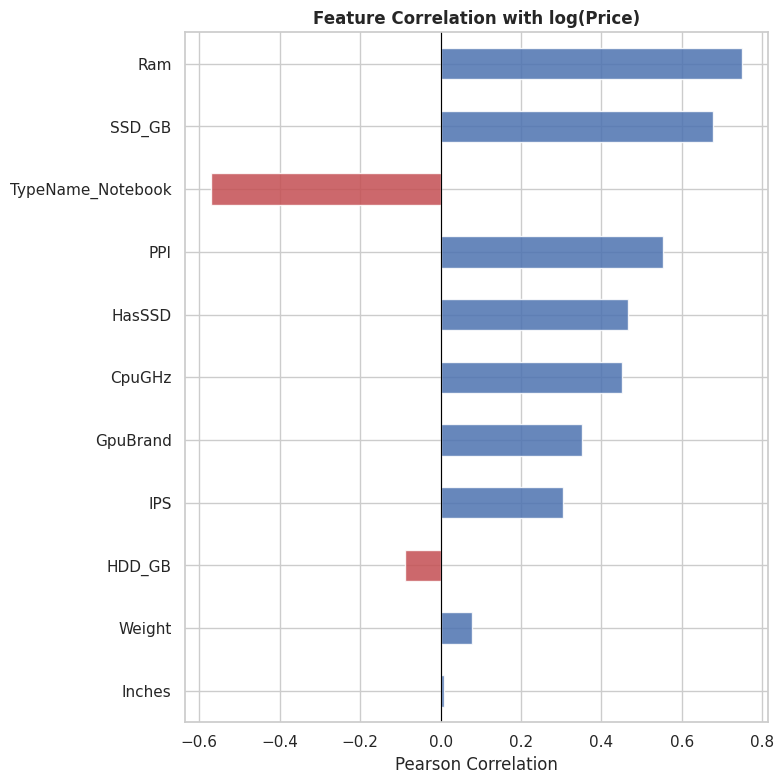

In [31]:
# Correlation heatmap with Price
# Rebuild X_train with target to check correlations
X_for_corr = X_train_scaled.copy()
X_for_corr['Price_euros'] = y_train.values
price_corr = X_for_corr.corr()['Price_euros'].drop('Price_euros').sort_values(key=abs, ascending=True)

plt.figure(figsize=(8, 8))
colors = ['#C44E52' if v < 0 else '#4C72B0' for v in price_corr.values]
price_corr.plot(kind='barh', color=colors, alpha=0.85, figsize=(8, 8))
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with log(Price)', fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

 **Simple Linear Regression**

In [49]:
X_train_simple = X_train_scaled.iloc[:, 0:1]
X_test_simple = X_test_scaled.iloc[:, 0:1]

simple_lr = LinearRegression()
simple_lr.fit(X_train_simple, y_train)
y_pred_simple = simple_lr.predict(X_test_simple)

evaluate_model("Simple LR (Inches)", y_test, y_pred_simple)

--- Simple LR (Inches) Performance ---
MAE:  0.4726
MSE:  0.3359
RMSE: 0.5795
R2:   0.0021



**Multiple Linear Regression**

In [52]:
multi_lr = LinearRegression()
multi_lr.fit(X_train_scaled, y_train)
y_pred_multi = multi_lr.predict(X_test_scaled)

evaluate_model("Multiple LR", y_test, y_pred_multi)

--- Multiple LR Performance ---
MAE:  0.2440
MSE:  0.0918
RMSE: 0.3030
R2:   0.7273



**Polynomial Regression (Degree 2)**

In [57]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_lr = LinearRegression()
poly_lr.fit(X_train_poly, y_train)
y_pred_poly = poly_lr.predict(X_test_poly)

evaluate_model("Polynomial Regression", y_test, y_pred_poly)

--- Polynomial Regression Performance ---
MAE:  0.2141
MSE:  0.0740
RMSE: 0.2720
R2:   0.7801



**Stochastic Gradient Descent (SGD)**

In [58]:
sgd = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
sgd.fit(X_train_scaled, y_train)
y_pred_sgd = sgd.predict(X_test_scaled)

evaluate_model("SGD Regressor", y_test, y_pred_sgd)

--- SGD Regressor Performance ---
MAE:  0.2441
MSE:  0.0914
RMSE: 0.3024
R2:   0.7284



 **Regularization (Ridge & Lasso)**

Comparing L2 (Ridge) and L1 (Lasso) penalties to prevent overfitting and perform feature selection.




In [61]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
evaluate_model("Ridge Regression", y_test, y_pred_ridge)

lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
evaluate_model("Lasso Regression", y_test, y_pred_lasso)

# Coefficient Comparison
coeff_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
})
print("\n--- Weight Impact Table ---")
display(coeff_df)

--- Ridge Regression Performance ---
MAE:  0.2440
MSE:  0.0918
RMSE: 0.3030
R2:   0.7273

--- Lasso Regression Performance ---
MAE:  0.2438
MSE:  0.0911
RMSE: 0.3019
R2:   0.7292


--- Weight Impact Table ---


,Feature,Ridge,Lasso
0,Inches,0.042034,0.021992
1,Ram,0.195800,0.207771
2,Weight,0.004394,0.001086
3,IPS,0.011186,0.006203
4,PPI,0.143757,0.126746
5,CpuGHz,0.136486,0.134243
6,GpuBrand,0.037420,0.034369
7,SSD_GB,0.147202,0.138157
8,HDD_GB,-0.000963,0.000000
9,HasSSD,-0.004971,0.000000


**The Grand Finale: Comparison & Visualization**

Final Model Comparison Table:


,MAE,MSE,RMSE,R2
Polynomial Regression,0.214136,0.074005,0.272038,0.780116
Lasso Regression,0.243815,0.091138,0.301891,0.729208
SGD Regressor,0.244086,0.091419,0.302356,0.728375
Multiple LR,0.243991,0.091792,0.302972,0.727265
Ridge Regression,0.244012,0.091795,0.302977,0.727257
Simple LR (Inches),0.472632,0.335857,0.579532,0.002096


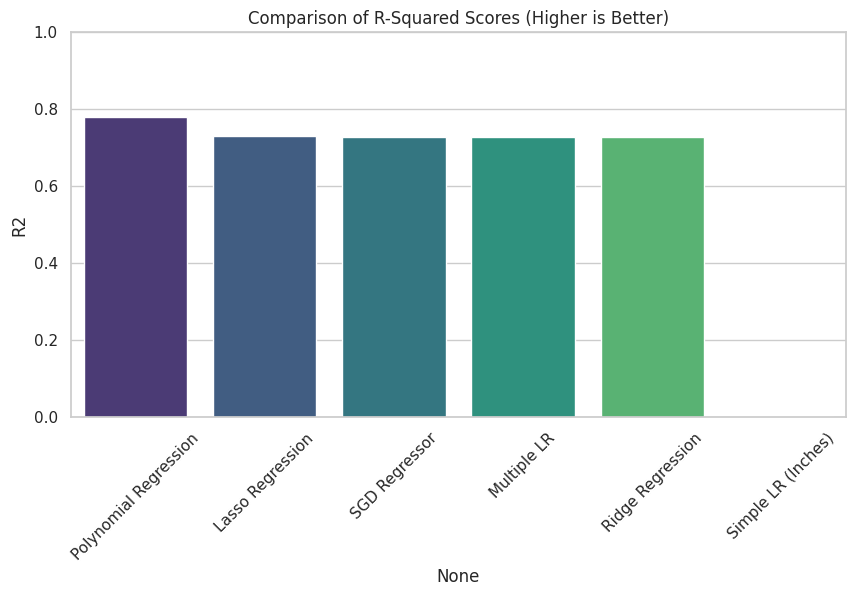

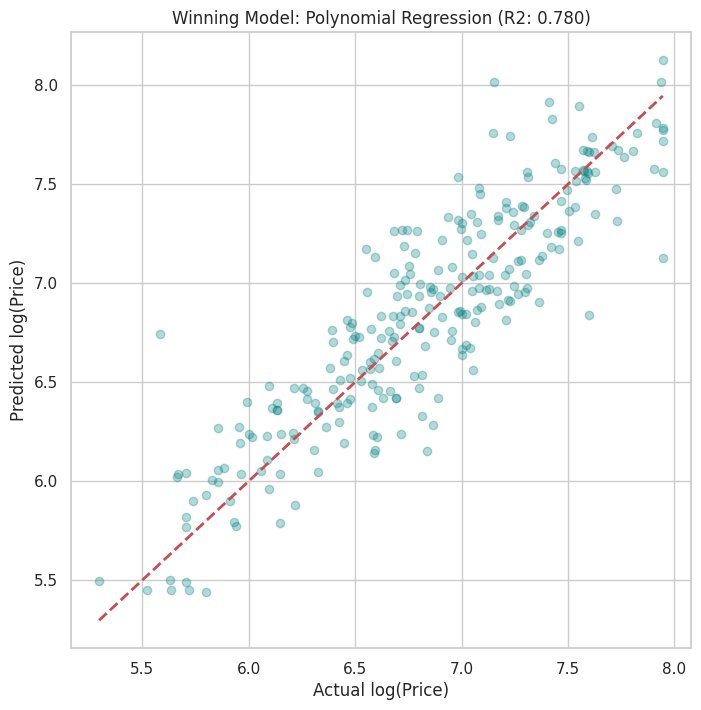

In [63]:
# 1. Metric Summary Table
summary_df = pd.DataFrame(results_log).T.sort_values(by='R2', ascending=False)
print("Final Model Comparison Table:")
display(summary_df)

# 2. Performance Visualization: R2 Comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=summary_df.index, y=summary_df['R2'], hue=summary_df.index, palette='viridis', legend=False)
plt.title("Comparison of R-Squared Scores (Higher is Better)")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

# 3. Best Model Actual vs. Predicted
best_model_name = summary_df.index[0]
best_model_r2 = summary_df.iloc[0]['R2']

# Get predictions for the best model
# Assuming y_pred_poly is for 'Polynomial Regression', if it's the best.
# If another model is best, we'd need its y_pred. For now, assuming Polynomial Regression is still the best or similar structure.
# For a more robust solution, we would need to store y_pred for each model in results_log.
# For this correction, let's assume y_pred_poly is still the target for this plot, but fix labels and title.

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_poly, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel("Actual log(Price)")
plt.ylabel("Predicted log(Price)")
plt.title(f"Winning Model: {best_model_name} (R2: {best_model_r2:.3f})")
plt.show()